In [1]:
import gdown

file_id = "1PcIYm8cIDgHolqvLkq15c_IgGp5y-WZc"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "contaminantes_2026.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1PcIYm8cIDgHolqvLkq15c_IgGp5y-WZc
To: /content/contaminantes_2026.csv
100%|██████████| 17.6M/17.6M [00:00<00:00, 153MB/s]


'contaminantes_2026.csv'

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

# Aplicar un estilo global más moderno
sns.set_theme(style="whitegrid", palette="muted")

ESTACION = "MER"

df = pd.read_csv("contaminantes_2026.csv", skiprows=9)
df["date"] = pd.to_datetime(df["date"])

df_est = df[df["id_station"] == ESTACION]

wide = df_est.pivot_table(index="date", columns="id_parameter", values="valor")
wide = wide[["O3", "NO", "NO2", "NOX", "CO"]].dropna()

print(wide.shape)
wide.head()

Regresión lineal: R², coeficientes y p-values

In [ ]:
X = wide[["NO", "NO2", "NOX", "CO"]]
y = wide["O3"]
X = sm.add_constant(X)

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                     O3   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.261
Method:                 Least Squares   F-statistic:                     114.0
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           3.62e-83
Time:                        03:28:25   Log-Likelihood:                -6062.3
No. Observations:                1283   AIC:                         1.213e+04
Df Residuals:                    1278   BIC:                         1.216e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         54.1022      2.134     25.354      0.0

VIF de cada variable

In [ ]:
vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

  variable           VIF
0    const      1.000000
1       NO  10180.456071
2      NO2   1194.140769
3      NOX  14676.660384
4       CO      5.964187


Residuos vs predichos + Breusch-Pagan

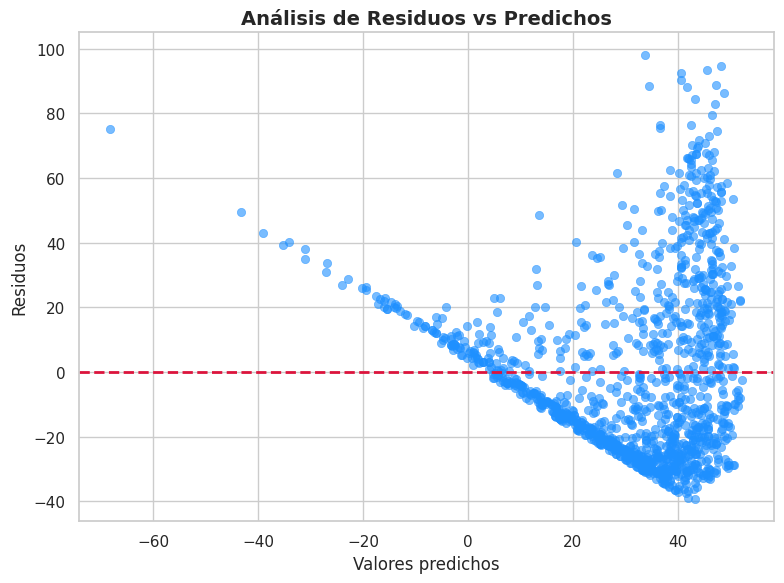

Breusch-Pagan estadístico: 76.0799, p-value: 1.1775e-15


In [ ]:
predichos = modelo.predict(X)
residuos = modelo.resid

plt.figure(figsize=(8, 6))
sns.scatterplot(x=predichos, y=residuos, alpha=0.6, color="dodgerblue", edgecolor=None)
plt.axhline(0, color="crimson", linestyle="--", linewidth=2)
plt.xlabel("Valores predichos", fontsize=12)
plt.ylabel("Residuos", fontsize=12)
plt.title("Análisis de Residuos vs Predichos", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

bp_stat, bp_pvalue, bp_f, bp_fpvalue = het_breuschpagan(residuos, X)
print(f"Breusch-Pagan estadístico: {bp_stat:.4f}, p-value: {bp_pvalue:.4e}")

Residuos en el tiempo, promedio por hora + Durbin-Watson

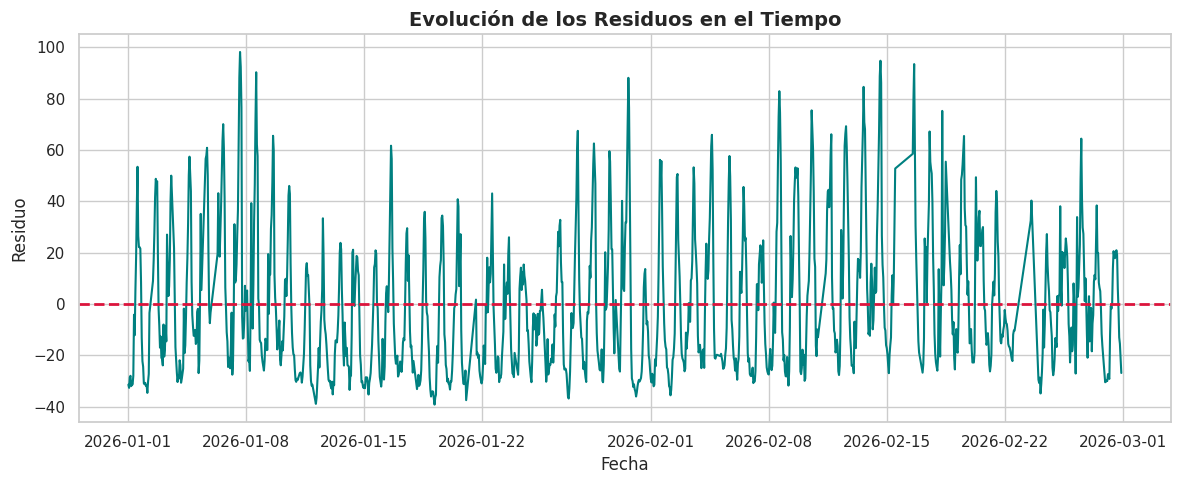

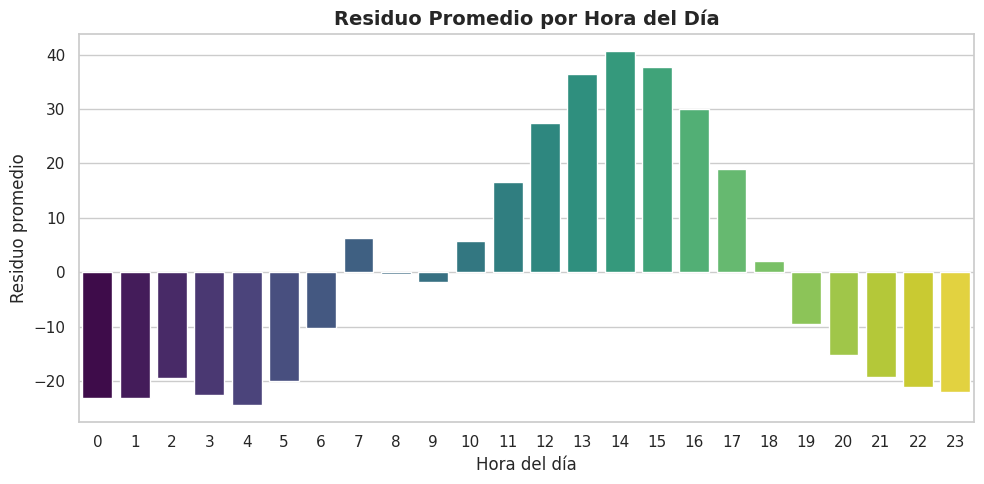

Durbin-Watson: 0.2302


In [ ]:
plt.figure(figsize=(12, 5))
sns.lineplot(x=wide.index, y=residuos, color="teal", linewidth=1.5)
plt.axhline(0, color="crimson", linestyle="--", linewidth=2)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Residuo", fontsize=12)
plt.title("Evolución de los Residuos en el Tiempo", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

wide_hora = wide.copy()
wide_hora["hora"] = wide_hora.index.hour
resid_por_hora = pd.Series(residuos.values, index=wide.index).groupby(wide_hora["hora"]).mean().reset_index(name='residuo_promedio')

plt.figure(figsize=(10, 5))
sns.barplot(data=resid_por_hora, x="hora", y="residuo_promedio", hue="hora", palette="viridis", legend=False)
plt.xlabel("Hora del día", fontsize=12)
plt.ylabel("Residuo promedio", fontsize=12)
plt.title("Residuo Promedio por Hora del Día", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

dw = durbin_watson(residuos)
print(f"Durbin-Watson: {dw:.4f}")

QQ-plot de los residuos

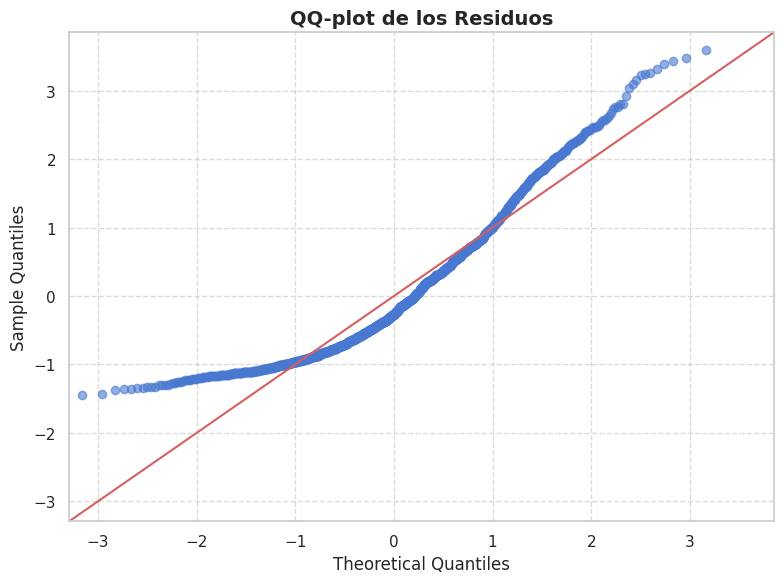

In [ ]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
sm.qqplot(residuos, line="45", fit=True, ax=ax, color="dodgerblue", alpha=0.6)
plt.title("QQ-plot de los Residuos", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()